In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt
from misc import compute_fft_with_windowing

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")


startup


In [3]:
def prepare_true_waveform(signal_row: np.ndarray, emri_kwargs: dict, add_kwargs: dict,add_noise: bool=False, use_gpu: bool = False,seed: Optional[int] = 0,nchannels: int = 3) -> dict:
    """
    Build fiducial 1PA waveform, PSD, and FFT from a signal parameter row.
    signal_row columns:
      [m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    """
    (
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0
    ) = signal_row

    waveform_response = build_waveform_response(T=emri_kwargs['T'], dt=emri_kwargs['dt'], use_gpu=use_gpu)

    chi2 = add_kwargs.get('chi2')
    deviation_included = add_kwargs.get('deviation_included', False)
    add_kwargs['evolve_1PA'] = True
    evolve_1PA = True
    evolve_primary = add_kwargs.get('evolve_primary', False)
    evolve_2PA = True
    dev_1 = add_kwargs.get('dev_1')
    dev_2 = add_kwargs.get('dev_2')
    dt = emri_kwargs['dt']
    T=emri_kwargs['T']
    noise= None

    wave_params = [
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included, dev_1, dev_2
    ]
    # emri_kwargs = {"T": T, "dt": dt, 'chi2': chi2, 'evolve_1PA': evolve_1PA, 'evolve_primary': evolve_primary,
    #                 'evolve_2PA': evolve_2PA,'deviation_included': deviation_included,'dev_1': dev_1, 'dev_2': dev_2}

    waveform_true = xp.array(waveform_response(*wave_params, **emri_kwargs))[0:nchannels,:]  # Shape (3, N) for A, E, T channels
    print("[INFO] Finished generating true waveform")
    
    channels = [A1TDISens, E1TDISens, T1TDISens]
    if nchannels == 3:
        noise_kwargs = [{"sens_fn": ch} for ch in channels]
    elif nchannels == 2:
        noise_kwargs = [{"sens_fn": ch} for ch in channels[:2]]
    else:
        raise ValueError(f"Unsupported number of channels: {nchannels}. Only 2 (A,E) or 3 (A,E,T) are supported.")
    PSD_funcs = generate_PSD(
        waveform=waveform_true,
        dt=dt,
        noise_PSD=get_sensitivity,
        channels=channels,
        noise_kwargs=noise_kwargs,
        use_gpu=use_gpu,
    )

    # Verify SNR level (grid builder normalized dist to target PA2 SNR already)
    PSD_funcs_ = xp.array(PSD_funcs)

    # print("type check - waveform_true:", type(waveform_true), "PSD_funcs:", type(PSD_funcs_), "dt:", type(dt))
    print("shape check - waveform_true:", xp.shape(waveform_true), "PSD_funcs:", xp.shape(PSD_funcs_))
    snr_2 = inner_product(waveform_true, waveform_true, PSD_funcs_, dt, use_gpu=use_gpu)
    #if hasattribute get u
    snr = np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2)
    print(f"[TRUE] SNR: {snr:.6f}")     
    for i in range(PSD_funcs_.shape[0]):    
       #check snr of each channel
         snr_i_2 = inner_product(waveform_true[i:i+1,], waveform_true[i:i+1,], PSD_funcs_[i:i+1,:], dt, use_gpu=use_gpu)
         snr_i = np.sqrt(snr_i_2.get()) if hasattr(snr_i_2, "get") else np.sqrt(snr_i_2)
         print(f"[TRUE] SNR - Channel {i}: {snr_i:.6f}")
    
         
    N_fiducial = len(waveform_true[0])
    freq=np.fft.rfftfreq(N_fiducial, dt)
    delta_f = freq[1] - freq[0]
    print(f"[INFO] Frequency resolution delta_f: {delta_f:.6e} Hz, Number of frequency bins: {len(freq)}")
    print(f"freq_max: {freq[-1]:.6f} Hz and Freq_min: {freq[1]:.6f} Hz")

    if add_noise:
        waveform_true_fft_without_noise = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=nchannels)
        plot_time_series_from_fft(waveform_true_fft_without_noise, dt, title="True Waveform without Noise (Time Domain)")
        waveform_true_fft,noise = add_noise_func(waveform_true_fft_without_noise,PSD_funcs_,delta_f, dt,n_channels= nchannels,seed=cfg.seed)
        print("[INFO] Added noise to true waveform FFT\n")
        print("shape of waveform_true_fft after noise addition:", xp.shape(waveform_true_fft))
        plot_time_series_from_fft(waveform_true_fft, dt, title="True Waveform with Noise (Time Domain)")
        noise_dict = check_noise_model_consistency(PSD_funcs_,delta_f,dt,n_channels=nchannels,temp_signal=waveform_true,seed=seed)
        print(f"Noise consistency check results: {noise_dict}")
        
    else:
        print("[INFO] No noise added to true waveform FFT\n")
        waveform_true_fft = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=nchannels)
        waveform_true_fft_without_noise = xp.copy(waveform_true_fft)  # Keep a copy of the clean FFT for later use
    
    print("[INFO] Finished preparing true waveform (GPU)")
    

    return {
        'm1': m1, 'm2': m2, 'a': a, 'p0': p0, 'e0': e0, 'Y0': Y0,
        'dist': dist, 'qS': qS, 'phiS': phiS, 'qK': qK, 'phiK': phiK,
        'Phi_phi0': Phi_phi0, 'Phi_theta0': Phi_theta0, 'Phi_r0': Phi_r0,
        'dt': dt, 'T': T, 'chi2': chi2,
        'dev_1': dev_1, 'dev_2': dev_2,
        'waveform_response': waveform_response,
        'PSD_funcs': PSD_funcs_,
        'waveform_true_fft': waveform_true_fft,
        'waveform_true_fft_without_noise': waveform_true_fft_without_noise,
        'N_fiducial': N_fiducial,
        'snr': snr,
        'delta_f': freq[1]-freq[0],
        'freq': freq,
        'noise_dict': noise_dict if add_noise else None,
        'noise': noise if add_noise else None,
    }
def build_waveform_response(T: float, dt: float, use_gpu: bool = False) -> ResponseWrapper:
    """Create a LISA ResponseWrapper consistent with existing modules."""

    sum_kwargs = dict(pad_output=False, odd_len=True)
    
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs, return_list=False,use_gpu=use_gpu)

    t0 = 10000.0
    tdi_gen = "1st generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS

    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend = "cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan="AET")

    print("[INFO] Finished loading modules and building ResponseWrapper")
    return response

In [4]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  

params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK","Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1000000.0, 10.0, 0.5, 10.0469014, 0.1, 1.0, 3.87879918, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3])

dt = 10 
T= 2.5
chi2 = 0.95
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False}
# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx_1gen = prepare_true_waveform(params, emri_kwargs, add_kwargs,add_noise=False, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx_1gen['waveform_true_fft_without_noise'], ctx_1gen['waveform_true_fft_without_noise'], ctx_1gen['PSD_funcs'], ctx_1gen['delta_f'], xp=xp)
print("snr", np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2))
ctx_1gen

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 7889537) PSD_funcs: (3, 3944768)
[TRUE] SNR: 44.815161
[TRUE] SNR - Channel 0: 31.564310
[TRUE] SNR - Channel 1: 31.813281
[TRUE] SNR - Channel 2: 0.090404
[INFO] Frequency resolution delta_f: 1.267502e-08 Hz, Number of frequency bins: 3944769
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz
[INFO] No noise added to true waveform FFT

[INFO] Finished preparing true waveform (GPU)
snr 44.815160924597166


{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.5),
 'p0': np.float64(10.0469014),
 'e0': np.float64(0.1),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.87879918),
 'qS': np.float64(1.04719755),
 'phiS': np.float64(0.785398163),
 'qK': np.float64(0.628318531),
 'phiK': np.float64(0.523598776),
 'Phi_phi0': np.float64(0.1),
 'Phi_theta0': np.float64(0.2),
 'Phi_r0': np.float64(0.3),
 'dt': 10,
 'T': 2.5,
 'chi2': 0.95,
 'dev_1': None,
 'dev_2': None,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552bc7758e0>,
 'PSD_funcs': array([[4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.25506202e-57, 1.70223871e-56, 3.83019753e-56, ...,
         5.36068302e-40, 5.36067435e-40, 5.36066568e-40]],
       shape=(3, 3944768)),
 'waveform_true_fft': array([[-7.

In [ ]:
Response = ctx_1gen["waveform_response"]
chi2 = 0.95
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
dt = emri_kwargs['dt']
T=emri_kwargs['T']
print(T)

wave_params = [1000021.4638514867, 10.000053818152267, 0.5000365332615887, 10.046728424296552, 0.0999881538593218, 1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
2.00000000e-01, 3.00000000e-01,0.95]
emri_kwargs = {"T": T, "dt": dt, 'chi2': 0.95, 'evolve_1PA': True, 'evolve_primary': False,
                'evolve_2PA': True}

waveform_check = xp.array(Response(*wave_params,**emri_kwargs))

2.5


In [9]:
waveform_check_fft = compute_fft_with_windowing(waveform_check, ctx_1gen['dt'], 0, use_gpu=True, n_channels=3)
waveform_check_fft.shape
# ctx_1gen['PSD_funcs'].shape

(3, 3944768)

In [10]:
inner_prod(ctx_1gen['waveform_true_fft'], waveform_check_fft, ctx_1gen['PSD_funcs'], ctx_1gen['delta_f'], xp=xp)

array(2008.22577497)

In [13]:
optimal_snr_true = inner_prod(ctx_1gen['waveform_true_fft'], ctx_1gen['waveform_true_fft'], ctx_1gen['PSD_funcs'], ctx_1gen['delta_f'], xp=xp)
optimal_snr_test = inner_prod(waveform_check_fft, waveform_check_fft, ctx_1gen['PSD_funcs'], ctx_1gen['delta_f'], xp=xp)
overlap = inner_prod(ctx_1gen['waveform_true_fft'], waveform_check_fft, ctx_1gen['PSD_funcs'], ctx_1gen['delta_f'], xp=xp) / np.sqrt(optimal_snr_true * optimal_snr_test)
overlap

array(0.99989569)

In [ ]:
# ctx_2gen = prepare_true_waveform_2gen(signal_param_array, emri_kwargs, add_kwargs,add_noise=False, use_gpu=True,seed=seed)

# snr_2 = inner_prod(ctx_2gen['waveform_true_fft_without_noise'], ctx_2gen['waveform_true_fft_without_noise'], ctx_2gen['PSD_funcs'], ctx_2gen['delta_f'], xp=xp)
# ctx_2gen

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 7889537) PSD_funcs: (3, 3944768)
[TRUE] SNR: 14177.655624
[TRUE] SNR - Channel 0: 51.718100
[TRUE] SNR - Channel 1: 51.060122
[TRUE] SNR - Channel 2: 14177.469347
[INFO] Frequency resolution delta_f: 1.267502e-08 Hz, Number of frequency bins: 3944769
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz
[INFO] Finished preparing true waveform (GPU)


{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.5),
 'p0': np.float64(10.0469014),
 'e0': np.float64(0.1),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.87879918),
 'qS': np.float64(1.04719755),
 'phiS': np.float64(0.785398163),
 'qK': np.float64(0.628318531),
 'phiK': np.float64(0.523598776),
 'Phi_phi0': np.float64(0.1),
 'Phi_theta0': np.float64(0.2),
 'Phi_r0': np.float64(0.3),
 'dt': 10,
 'T': 2.5,
 'chi2': 0.95,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x155252734890>,
 'PSD_funcs': array([[3.00697098e-45, 3.00697098e-45, 3.00697100e-45, ...,
         4.81903195e-40, 4.81901451e-40, 4.81899708e-40],
        [3.00697098e-45, 3.00697098e-45, 3.00697100e-45, ...,
         4.81903195e-40, 4.81901451e-40, 4.81899708e-40],
        [3.00276393e-68, 4.80502610e-67, 2.43264635e-66, ...,
         1.60146584e-39, 1.60146077e-39, 1.60145570e-39]],
       shape=(3, 3944768)),
 'waveform_true_fft': array([[-7.56500901e-23-1.48939999e-25j, -7

In [65]:
ctx_1gen['PSD_funcs'][0]

array([4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
       1.61310358e-40, 1.61310024e-40, 1.61309690e-40], shape=(3944768,))

/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


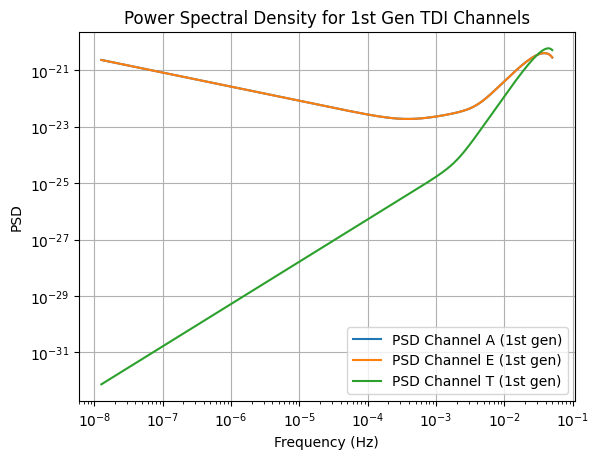

In [14]:
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][0].get()*ctx_1gen['freq'][1:]), label='PSD Channel A (1st gen)')
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][1].get()*ctx_1gen['freq'][1:]), label='PSD Channel E (1st gen)')
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][2].get()*ctx_1gen['freq'][1:]), label='PSD Channel T (1st gen)')

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Power Spectral Density for 1st Gen TDI Channels')
plt.legend()
plt.grid()
plt.show()

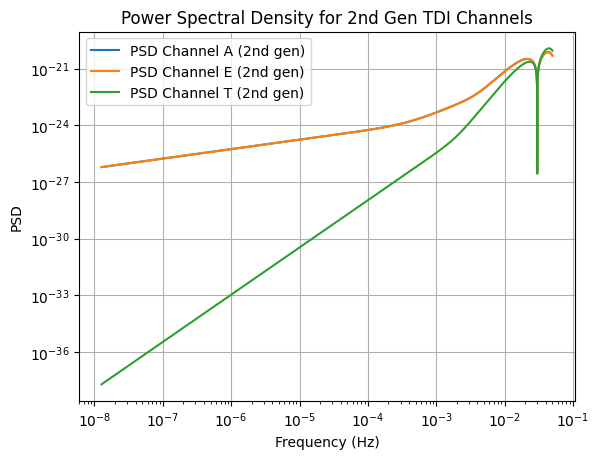

In [46]:

plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][0].get()*ctx_2gen['freq'][1:]), label='PSD Channel A (2nd gen)')
plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][1].get()*ctx_2gen['freq'][1:]), label='PSD Channel E (2nd gen)')
plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][2].get()*ctx_2gen['freq'][1:]), label='PSD Channel T (2nd gen)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Power Spectral Density for 2nd Gen TDI Channels')
plt.legend()
plt.grid()
plt.show()

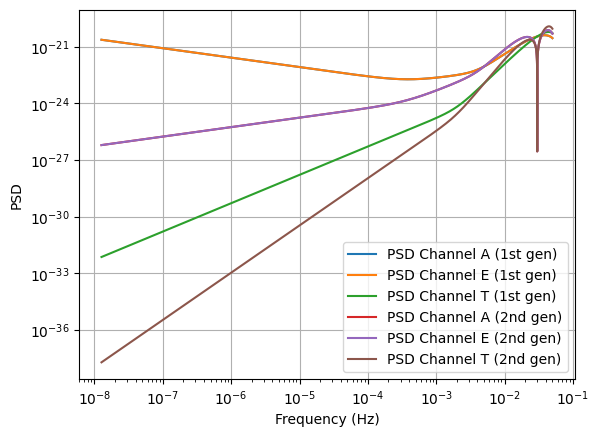

In [47]:
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][0].get()*ctx_1gen['freq'][1:]), label='PSD Channel A (1st gen)')
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][1].get()*ctx_1gen['freq'][1:]), label='PSD Channel E (1st gen)')
plt.loglog(ctx_1gen['freq'][1:], np.sqrt(ctx_1gen['PSD_funcs'][2].get()*ctx_1gen['freq'][1:]), label='PSD Channel T (1st gen)')
plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][0].get()*ctx_2gen['freq'][1:]), label='PSD Channel A (2nd gen)')
plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][1].get()*ctx_2gen['freq'][1:]), label='PSD Channel E (2nd gen)')
plt.loglog(ctx_2gen['freq'][1:], np.sqrt(ctx_2gen['PSD_funcs'][2].get()*ctx_2gen['freq'][1:]), label='PSD Channel T (2nd gen)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
#plt.title('Power Spectral Density for 1st Gen TDI Channels')
plt.legend()
plt.grid()
plt.show()

In [66]:
# 1st gen
Respsone = ctx_1gen['waveform_response']

/tmp/ipykernel_3871728/1783740538.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


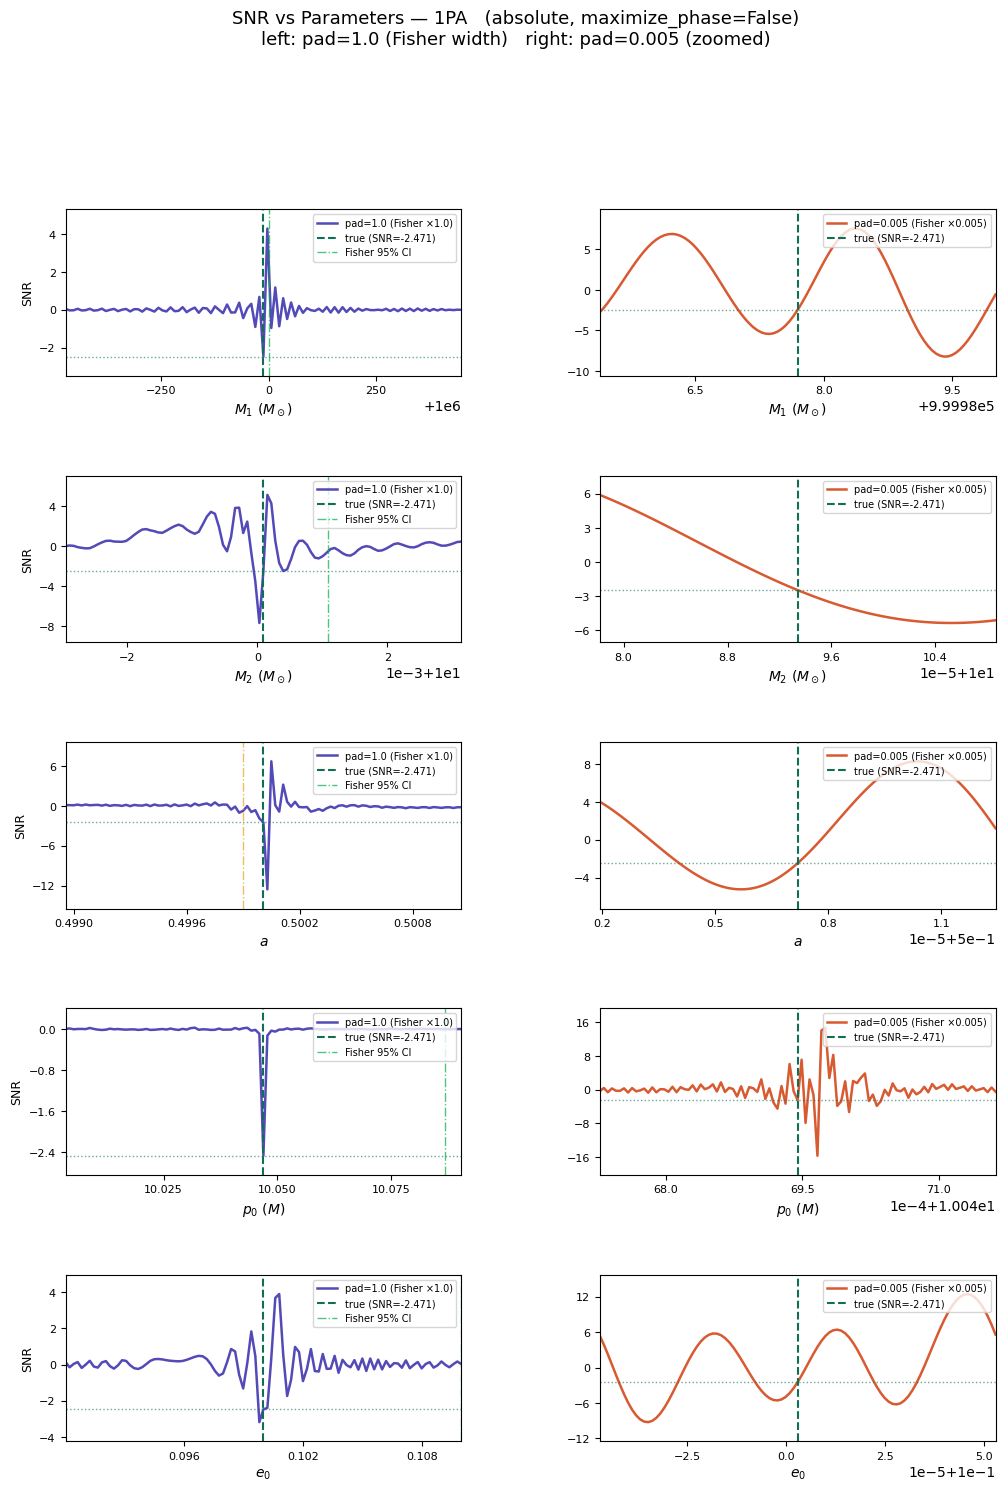

In [ ]:
from matplotlib.gridspec import GridSpec

optimized_params = [9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
1.00002900e-01,1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
2.00000000e-01, 3.00000000e-01]


# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$']

x_best_fit_0PA = [9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
                  1.00002900e-01]

fisher_bounds = [(9.9907696e+05, 10**6),
                 (9.995,         1.00010934e+01),
                 (0.4999,        0.502),
                 (10,            1.00869448e+01),
                 (0.09,          0.11)]

PARAM_BOUNDS = [
    (None,    None),
    (None,    None),
    (-0.9999, 0.9999),
    (1.0,     None),
    (0.0,     0.9999)]

add_kwargs = {'chi2': 9.49999735e-01, 'evolve_1PA': False, 'evolve_primary': False, 'evolve_2PA': True,
              'deviation_included': False, 'dev_1': 0, 'dev_2': 0}

fixed = {
    'waveform_response': ctx_1gen['waveform_response'],
    'PSD':               ctx_1gen['PSD_funcs'],
    'dt':                ctx_1gen['dt'],
    'T':                 ctx_1gen['T'],
    'N_fiducial':        ctx_1gen['N_fiducial'],
    'waveform_true_fft': ctx_1gen['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx_1gen['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA)
N_POINTS    = 100
PAD_FACTORS = [1.0, 0.005]


# ── Grid builder ───────────────────────────────────────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = fisher_bounds[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA)          # 5 intrinsic params only
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0 = theta         # ← fixed: unpack only 5 values
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0,
            ctx_1gen['Y0'], ctx_1gen['dist'],
            ctx_1gen['qS'], ctx_1gen['phiS'],
            ctx_1gen['qK'], ctx_1gen['phiK'],
            ctx_1gen['Phi_phi0'], ctx_1gen['Phi_theta0'], ctx_1gen['Phi_r0'],
            add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)
    nrows = N_PARAMS

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)
            ax.axvline(x_best_fit_0PA[idx], color='#0F6E56',
                       lw=1.5, ls='--',
                       label=f'true (SNR={snr_true:.3f})')

            if col == 0:
                lo, hi = fisher_bounds[idx]
                ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
                ax.axvline(hi, color="#02AE44", lw=1.0, ls='-.',  alpha=0.7,
                           label='Fisher 95% CI')

            ax.set_xlim(grid[0], grid[-1])

            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else snr_true * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 1PA   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.005 (zoomed)',  # ← fixed
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [69]:
fixed = {
    'waveform_response': ctx_1gen['waveform_response'],
    'PSD':               ctx_1gen['PSD_funcs'],
    'dt':                ctx_1gen['dt'],
    'T':                 ctx_1gen['T'],
    'N_fiducial':        ctx_1gen['N_fiducial'],
    'waveform_true_fft': ctx_1gen['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx_1gen['delta_f'],
    'use_gpu':           True,
}
calculate_detection_snr_0pa_vs_1pa(9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
1.00002900e-01,ctx_1gen['Y0'], ctx_1gen['dist'],
            ctx_1gen['qS'], ctx_1gen['phiS'],
            ctx_1gen['qK'], ctx_1gen['phiK'],
            ctx_1gen['Phi_phi0'], ctx_1gen['Phi_theta0'], ctx_1gen['Phi_r0'],
            add_kwargs,
            maximize_phase=False,
            **fixed)

-2.4711559106874352

In [70]:
fixed = {
    'waveform_response': ctx_2gen['waveform_response'],
    'PSD':               ctx_2gen['PSD_funcs'][0:2],
    'dt':                ctx_2gen['dt'],
    'T':                 ctx_2gen['T'],
    'N_fiducial':        ctx_2gen['N_fiducial'],
    'waveform_true_fft': ctx_2gen['waveform_true_fft'][0:2],
    'xp':                np,
    'delta_f':           ctx_2gen['delta_f'],
    'use_gpu':           True,
}
calculate_detection_snr_0pa_vs_1pa(9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
1.00002900e-01,ctx_1gen['Y0'], ctx_2gen['dist'],
            ctx_2gen['qS'], ctx_2gen['phiS'],
            ctx_2gen['qK'], ctx_2gen['phiK'],
            ctx_2gen['Phi_phi0'], ctx_2gen['Phi_theta0'], ctx_2gen['Phi_r0'],
            add_kwargs,
            maximize_phase=False,
            **fixed)

3.956562853347899

In [71]:
def build_waveform_response_(T: float, dt: float, use_gpu: bool = False) -> ResponseWrapper:
    """Create a LISA ResponseWrapper consistent with existing modules."""

    sum_kwargs=dict(pad_output=False, odd_len=True)
    inspiral_kwargs=dict(err=1e-11)
    mode_selector_kwargs=dict(mode_selection_threshold=1e-5)
    
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs,inspiral_kwargs=inspiral_kwargs, mode_selector_kwargs=mode_selector_kwargs, return_list=False,use_gpu=use_gpu)

    t0 = 10000.0  # Start time of the waveform in seconds
    tdi_gen = "1st generation"
    order = 20
    
    index_lambda = 8  # phiS
    index_beta = 7    # qS

    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend = "cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan="AET",
    )

    print("[INFO] Finished loading modules and building ResponseWrapper")
    return response

def prepare_true_waveform_1gen_1proj(signal_row: np.ndarray, emri_kwargs: dict, add_kwargs: dict,add_noise: bool=False, use_gpu: bool = False,seed: Optional[int] = 0,nchannels: int = 3) -> dict:
    (
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0
    ) = signal_row

    if use_gpu:
        xp=cp
    else:
        xp=np

    waveform_response = build_waveform_response_(T=emri_kwargs['T'], dt=emri_kwargs['dt'], use_gpu=use_gpu)

    chi2 = add_kwargs.get('chi2')
    add_kwargs['evolve_1PA'] = True
    evolve_1PA = add_kwargs['evolve_1PA']
    evolve_primary = add_kwargs.get('evolve_primary', False)
    evolve_2PA = add_kwargs.get('evolve_2PA',False)

    dt = emri_kwargs['dt']
    T=emri_kwargs['T']
    noise= None

    wave_params = [
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,chi2, evolve_1PA, evolve_primary, evolve_2PA
    ]
    # emri_kwargs = {"T": T, "dt": dt, 'chi2': chi2, 'evolve_1PA': evolve_1PA, 'evolve_primary': evolve_primary,
    #                 'evolve_2PA': evolve_2PA,'deviation_included': deviation_included,'dev_1': dev_1, 'dev_2': dev_2}

    waveform_true = xp.array(waveform_response(*wave_params))[0:nchannels,:]  # Shape (3, N) for A, E, T channels
    print("[INFO] Finished generating true waveform")
    
    channels = [A1TDISens, E1TDISens, T1TDISens]
    if nchannels == 3:
        noise_kwargs = [{"sens_fn": ch} for ch in channels]
    elif nchannels == 2:
        noise_kwargs = [{"sens_fn": ch} for ch in channels[:2]]
    else:
        raise ValueError(f"Unsupported number of channels: {nchannels}. Only 2 (A,E) or 3 (A,E,T) are supported.")
    PSD_funcs = generate_PSD(
        waveform=waveform_true,
        dt=dt,
        noise_PSD=get_sensitivity,
        channels=channels,
        noise_kwargs=noise_kwargs,
        use_gpu=use_gpu,
    )

    # Verify SNR level (grid builder normalized dist to target PA2 SNR already)
    PSD_funcs_ = xp.array(PSD_funcs)

    # print("type check - waveform_true:", type(waveform_true), "PSD_funcs:", type(PSD_funcs_), "dt:", type(dt))
    print("shape check - waveform_true:", xp.shape(waveform_true), "PSD_funcs:", xp.shape(PSD_funcs_))
    waveform_true = xp.array(waveform_true)
    PSD_funcs_ = xp.array(PSD_funcs_)
    snr_2 = inner_product(waveform_true, waveform_true, PSD_funcs_, dt, use_gpu=use_gpu)
    #if hasattribute get u
    snr = np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2)
    print(f"[TRUE] SNR: {snr:.6f}")     

    for i in range(PSD_funcs_.shape[0]):    
       #check snr of each channel
         snr_i_2 = inner_product(waveform_true[i:i+1,], waveform_true[i:i+1,], PSD_funcs_[i:i+1,:], dt, use_gpu=use_gpu)
         snr_i = np.sqrt(snr_i_2.get()) if hasattr(snr_i_2, "get") else np.sqrt(snr_i_2)
         print(f"[TRUE] SNR - Channel {i}: {snr_i:.6f}")
    
         
    N_fiducial = len(waveform_true[0])
    freq=np.fft.rfftfreq(N_fiducial, dt)
    delta_f = freq[1] - freq[0]
    print(f"[INFO] Frequency resolution delta_f: {delta_f:.6e} Hz, Number of frequency bins: {len(freq)}")
    print(f"freq_max: {freq[-1]:.6f} Hz and Freq_min: {freq[1]:.6f} Hz")


    waveform_true_fft = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=nchannels)
    waveform_true_fft_without_noise = xp.copy(waveform_true_fft)  # Keep a copy of the clean FFT for later use
    
    print("[INFO] Finished preparing true waveform (GPU)")
    return {
        'm1': m1, 'm2': m2, 'a': a, 'p0': p0, 'e0': e0, 'Y0': Y0,
        'dist': dist, 'qS': qS, 'phiS': phiS, 'qK': qK, 'phiK': phiK,
        'Phi_phi0': Phi_phi0, 'Phi_theta0': Phi_theta0, 'Phi_r0': Phi_r0,
        'dt': dt, 'T': T, 'chi2': chi2,
        'waveform_response': waveform_response,
        'PSD_funcs': PSD_funcs_,
        'waveform_true_fft': waveform_true_fft,
        'waveform_true_fft_without_noise': waveform_true_fft_without_noise,
        'N_fiducial': N_fiducial,
        'snr': snr,
        'delta_f': freq[1]-freq[0],
        'freq': freq,
    }
    
    seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1.00000000e+06, 1.00000000e+01, 5.00000000e-01, 1.00469014e+01,
1.00000000e-01, 1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
2.00000000e-01, 3.00000000e-01])


signal_param_array = params
dt = 10  #Time step for waveform generation; default 0.1s
T= 2.5

chi2 = 0.95
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx_1gen_1 = prepare_true_waveform_1gen_1proj(signal_param_array, emri_kwargs, add_kwargs,add_noise=False, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx_1gen_1['waveform_true_fft_without_noise'], ctx_1gen_1['waveform_true_fft_without_noise'], ctx_1gen_1['PSD_funcs'], ctx_1gen_1['delta_f'], xp=xp)
ctx_1gen_1

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 7889537) PSD_funcs: (3, 3944768)
[TRUE] SNR: 44.815162
[TRUE] SNR - Channel 0: 31.564311
[TRUE] SNR - Channel 1: 31.813282
[TRUE] SNR - Channel 2: 0.090409
[INFO] Frequency resolution delta_f: 1.267502e-08 Hz, Number of frequency bins: 3944769
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz
[INFO] Finished preparing true waveform (GPU)


{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.5),
 'p0': np.float64(10.0469014),
 'e0': np.float64(0.1),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.87879918),
 'qS': np.float64(1.04719755),
 'phiS': np.float64(0.785398163),
 'qK': np.float64(0.628318531),
 'phiK': np.float64(0.523598776),
 'Phi_phi0': np.float64(0.1),
 'Phi_theta0': np.float64(0.2),
 'Phi_r0': np.float64(0.3),
 'dt': 10,
 'T': 2.5,
 'chi2': 0.95,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552502060c0>,
 'PSD_funcs': array([[4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.25506202e-57, 1.70223871e-56, 3.83019753e-56, ...,
         5.36068302e-40, 5.36067435e-40, 5.36066568e-40]],
       shape=(3, 3944768)),
 'waveform_true_fft': array([[-7.56859534e-23-1.48968523e-25j, -7

In [77]:
fixed = {
    'waveform_response': ctx_1gen_1['waveform_response'],
    'PSD':               ctx_1gen_1['PSD_funcs'],
    'dt':                ctx_1gen_1['dt'],
    'T':                 ctx_1gen_1['T'],
    'N_fiducial':        ctx_1gen_1['N_fiducial'],
    'waveform_true_fft': ctx_1gen_1['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx_1gen_1['delta_f'],
    'use_gpu':           True,
}
add_kwargs = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': False,
                   'dev_1': 0, 'dev_2': 0}
calculate_detection_snr_0pa_vs_1pa(9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
1.00002900e-01,ctx_1gen_1['Y0'], ctx_1gen_1['dist'],
            ctx_1gen_1['qS'], ctx_1gen_1['phiS'],
            ctx_1gen_1['qK'], ctx_1gen_1['phiK'],
            ctx_1gen_1['Phi_phi0'], ctx_1gen_1['Phi_theta0'], ctx_1gen_1['Phi_r0'],
            add_kwargs,
            maximize_phase=False,
            **fixed)

-0.32785732963055375